# Fine-scale population genomics around Crete

Clean local analysis notebook for the rerun of the `Pop_Genomics` Snakemake workflow.

Main manuscript analyses are placed first. Exploratory or currently unused analyses are collected in the **Appendix** at the end.

## Expected local folder structure

```text
CretePopGenomics_local/
├── notebooks/
├── data/
│   ├── snakemake/
│   │   ├── AF/
│   │   ├── pca/
│   │   ├── admixture/
│   │   ├── distance/
│   │   ├── popgenwindows/
│   │   ├── TajimasD/
│   │   ├── Dtrios/
│   │   ├── astral/
│   │   └── heterozygosity_genome/
│   ├── metadata/
│   │   └── pop_info/
│   └── external/
│       └── GCF_900634775.1_fGouWil2.1_genomic_chromnames.gtf
└── results/
    ├── figures/
    ├── tables/
    ├── splitstree/
    └── candidate_genes/
```


## 1. Setup
Run this notebook from the `notebooks/` folder. Paths are relative to the local project root.


In [63]:
from pathlib import Path
import itertools
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

try:
    import seaborn as sns
    sns.set_context("talk")
except Exception:
    sns = None

import matplotlib as mpl

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"

PROJECT_ROOT = Path("..").resolve()
DATA = PROJECT_ROOT / "data"
SNAKEMAKE = DATA / "snakemake"
METADATA = DATA / "metadata"
EXTERNAL = DATA / "external"
RESULTS = PROJECT_ROOT / "results"
FIGURES = RESULTS / "figures"
TABLES = RESULTS / "tables"
SPLITSTREE = RESULTS / "splitstree"
CANDIDATES = RESULTS / "candidate_genes"

for d in [FIGURES, TABLES, SPLITSTREE, CANDIDATES]:
    d.mkdir(parents=True, exist_ok=True)

SPECIES = ["orientalis", "hofrichteri"]
SPECIES_LABELS = {"orientalis": r"$G. orientalis$", "hofrichteri": r"$G. hofrichteri$"}
POP_ORDER = ["Kythira", "NNE-Mades", "NW-Petres", "SE-Vatos", "SW-Plakias"]
POP_COLORS = {
    "Kythira": "#7B3294", "NNE-Mades": "#4575B4", "NW-Petres": "#74ADD1",
    "SE-Vatos": "#F46D43", "SW-Plakias": "#D73027", "Outgroup": "#999999"
}
SNP_SUFFIX = "variants.tif1.sft1.pass.snps.biallelic"
ALLSITES_SUFFIX = "all_sites.tif1.sft1.no_indels.biallelic"
WINDOW_LABEL = "w60000.m100.s30000"

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


## 2. Helper functions


In [64]:
def require_file(path, description=None):
    path = Path(path)
    if not path.exists():
        msg = f"Missing file: {path}"
        if description:
            msg += f"\nExpected: {description}"
        raise FileNotFoundError(msg)
    return path


def savefig(name, **kwargs):
    png = FIGURES / f"{name}.png"
    pdf = FIGURES / f"{name}.pdf"
    plt.savefig(png, dpi=300, bbox_inches="tight", **kwargs)
    plt.savefig(pdf, bbox_inches="tight", **kwargs)
    print(f"saved: {png}")
    print(f"saved: {pdf}")


def parse_sample(sample):
    parts = str(sample).split("_")
    out = {"sample": sample, "species": None, "population": None}
    for sp in SPECIES:
        if sp in parts:
            out["species"] = sp
            idx = parts.index(sp)
            if idx + 1 < len(parts):
                out["population"] = "_".join(parts[idx + 1:]).replace("_", "-")
            break
    return out


def read_popmap(path):
    df = pd.read_csv(path, sep=r"\s+", header=None, names=["sample", "population"])
    parsed = pd.DataFrame([parse_sample(s) for s in df["sample"]])
    return pd.concat([df, parsed.drop(columns=["sample"])], axis=1)


def species_popmap(species, no_outgroup=True):
    suffix = ".no_outgroup" if no_outgroup else ""
    path = METADATA / "pop_info" / f"{species}_pop{suffix}.info"
    if not path.exists():
        path = METADATA / "pop_info" / f"{species}_pop.info"
    return read_popmap(require_file(path))


def pair_columns(df, prefix):
    return [c for c in df.columns if c.startswith(prefix + "_")]


## 3. Input check


In [65]:
expected_dirs = {
    "AF": SNAKEMAKE / "AF",
    "pca": SNAKEMAKE / "pca",
    "admixture": SNAKEMAKE / "admixture",
    "distance": SNAKEMAKE / "distance",
    "popgenwindows": SNAKEMAKE / "popgenwindows",
    "TajimasD": SNAKEMAKE / "TajimasD",
    "Dtrios": SNAKEMAKE / "Dtrios",
    "astral": SNAKEMAKE / "astral",
    "heterozygosity_genome": SNAKEMAKE / "heterozygosity_genome",
    "metadata/pop_info": METADATA / "pop_info",
    "external": EXTERNAL,
}
for name, path in expected_dirs.items():
    status = "OK" if path.exists() else "MISSING"
    print(f"{status:8s} {name:25s} {path}")


OK       AF                        /Users/maximilianwagner/Desktop/CretePopGenomics_local/data/snakemake/AF
OK       pca                       /Users/maximilianwagner/Desktop/CretePopGenomics_local/data/snakemake/pca
OK       admixture                 /Users/maximilianwagner/Desktop/CretePopGenomics_local/data/snakemake/admixture
OK       distance                  /Users/maximilianwagner/Desktop/CretePopGenomics_local/data/snakemake/distance
OK       popgenwindows             /Users/maximilianwagner/Desktop/CretePopGenomics_local/data/snakemake/popgenwindows
OK       TajimasD                  /Users/maximilianwagner/Desktop/CretePopGenomics_local/data/snakemake/TajimasD
OK       Dtrios                    /Users/maximilianwagner/Desktop/CretePopGenomics_local/data/snakemake/Dtrios
OK       astral                    /Users/maximilianwagner/Desktop/CretePopGenomics_local/data/snakemake/astral
OK       heterozygosity_genome     /Users/maximilianwagner/Desktop/CretePopGenomics_local/data/sn

# Main analyses


## 4. Genome-wide heterozygosity and FIS


In [66]:
def read_het(species):
    path = SNAKEMAKE / "heterozygosity_genome" / f"{species}_{SNP_SUFFIX}.het"
    df = pd.read_csv(require_file(path), sep=r"\s+")
    df = df.rename(columns={"INDV": "sample", "F": "FIS"})
    meta = pd.DataFrame([parse_sample(s) for s in df["sample"]])
    df = pd.concat([df, meta.drop(columns=["sample"])], axis=1)
    return df

het = pd.concat([read_het(sp) for sp in SPECIES], ignore_index=True)
#het.head()
het

,sample,O(HOM),E(HOM),N_SITES,FIS,species,population
0,D13_orientalis_Kythira,4927799,4894453.4,5487654,0.05621,orientalis,Kythira
1,D14_orientalis_Kythira,4922390,4888773.7,5481209,0.05674,orientalis,Kythira
2,D15_orientalis_Kythira,4836328,4773772.4,5321192,0.11427,orientalis,Kythira
3,D16_orientalis_Kythira,4739420,4664843.3,5180205,0.14471,orientalis,Kythira
4,D17_orientalis_Kythira,4746252,4668865.9,5185242,0.14986,orientalis,Kythira
...,...,...,...,...,...,...,...
80,D68_hofrichteri_SW-Plakias,2306271,2324321.7,2752139,-0.04219,hofrichteri,SW-Plakias
81,D69_hofrichteri_SW-Plakias,2325338,2337394.8,2763431,-0.02830,hofrichteri,SW-Plakias
82,D70_hofrichteri_SW-Plakias,2318901,2330880.4,2758186,-0.02803,hofrichteri,SW-Plakias
83,D71_hofrichteri_SW-Plakias,2300611,2307939.0,2719307,-0.01781,hofrichteri,SW-Plakias


In [67]:
summary_het = (
    het.groupby(["species", "population"], dropna=False)
    .agg(n=("sample", "count"), mean_FIS=("FIS", "mean"), sd_FIS=("FIS", "std"), mean_sites=("N_SITES", "mean"))
    .reset_index()
)
summary_het.to_csv(TABLES / "heterozygosity_FIS_summary.tsv", sep="	", index=False)
summary_het


,species,population,n,mean_FIS,sd_FIS,mean_sites
0,hofrichteri,Kythira,12,0.072943,0.015508,2.713499e+06
1,hofrichteri,NNE-Mades,6,-0.044588,0.019489,2.752234e+06
2,hofrichteri,NW-Petres,6,-0.046307,0.017295,2.780073e+06
3,hofrichteri,SE-Vatos,5,-0.077586,0.035548,2.807109e+06
4,hofrichteri,SW-Plakias,10,-0.031976,0.022263,2.755486e+06
5,orientalis,Kythira,12,0.118609,0.035864,5.213868e+06
6,orientalis,NNE-Mades,1,-0.058470,NaN,5.501922e+06
7,orientalis,NW-Petres,8,0.003630,0.028028,5.355808e+06
8,orientalis,SE-Vatos,12,-0.078143,0.038146,5.358072e+06
9,orientalis,SW-Plakias,13,-0.070982,0.046210,5.322733e+06


saved: /Users/maximilianwagner/Desktop/CretePopGenomics_local/results/figures/FIS_split_violin_by_population.png
saved: /Users/maximilianwagner/Desktop/CretePopGenomics_local/results/figures/FIS_split_violin_by_population.pdf


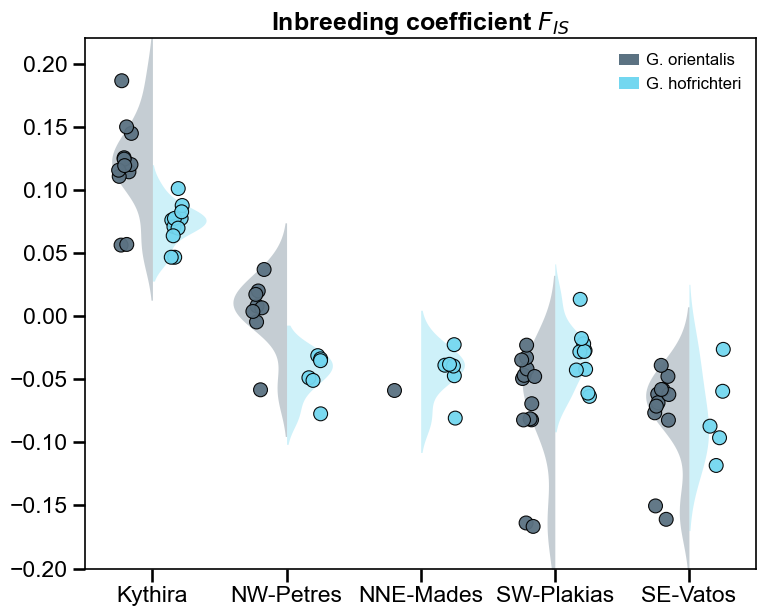

In [68]:
POP_ORDER = ["Kythira", "NW-Petres", "NNE-Mades", "SW-Plakias", "SE-Vatos"]

species_palette = {
    "G. orientalis": "#5B7282",
    "G. hofrichteri": "#73D7F0",
}

plot_df = het.copy().rename(
    columns={
        "population": "POP",
        "species": "Species",
        "FIS": "F",
    }
)

plot_df["Species"] = plot_df["Species"].replace({
    "orientalis": "G. orientalis",
    "hofrichteri": "G. hofrichteri",
})

plot_df["POP"] = pd.Categorical(
    plot_df["POP"],
    categories=POP_ORDER,
    ordered=True,
)

fig, ax = plt.subplots(figsize=(8, 6.5))

# Violin plots
sns.violinplot(
    data=plot_df,
    x="POP",
    y="F",
    hue="Species",
    order=POP_ORDER,
    palette=species_palette,
    split=True,
    inner=None,
    linewidth=0,
    bw_adjust=1,
    cut=2,
    saturation=1,
    ax=ax,
)

# Make violins semi-transparent
n_violin_collections = len(POP_ORDER) * 2
for coll in ax.collections[:n_violin_collections]:
    coll.set_alpha(0.35)

# Individual samples
sns.stripplot(
    data=plot_df,
    x="POP",
    y="F",
    hue="Species",
    order=POP_ORDER,
    palette=species_palette,
    dodge=True,
    jitter=0.12,
    size=10,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.95,
    ax=ax,
)



# Labels
ax.set_xlabel("")
#ax.set_ylabel(r"Inbreeding coefficient $F_{IS}$", fontsize=13)
ax.set_ylabel("")
ax.set_title(
    r"Inbreeding coefficient $F_{IS}$",
    fontsize=18,
    fontweight="bold",
)

# Limits
ax.set_ylim(-0.20, 0.22)

# Full border box
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

# Clean duplicated legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[:2],
    labels[:2],
    frameon=False,
    title=None,
    fontsize=12,
    loc="upper right",
    handlelength=1.2,
    handletextpad=0.4,
)

plt.tight_layout()

savefig("FIS_split_violin_by_population")

plt.show()

## 5. Population structure: PCA


In [69]:
def find_pca_files(species, maf="0.15"):
    pca_dir = SNAKEMAKE / "pca"
    vec = sorted(pca_dir.glob(f"{species}_{SNP_SUFFIX}.pca.maf{maf}.eigenvec"))
    val = sorted(pca_dir.glob(f"{species}_{SNP_SUFFIX}.pca.maf{maf}.eigenval"))
    if not vec:
        vec = sorted(pca_dir.glob(f"{species}_{SNP_SUFFIX}.pca.maf*.eigenvec"))
        val = sorted(pca_dir.glob(f"{species}_{SNP_SUFFIX}.pca.maf*.eigenval"))
    return require_file(vec[0]), require_file(val[0])


def read_plink2_pca(species, maf="0.15"):
    vec, val = find_pca_files(species, maf)
    df = pd.read_csv(vec, sep=r"\s+")
    df.columns = [c.lstrip("#") for c in df.columns]
    sample_col = "IID" if "IID" in df.columns else df.columns[0]
    df = df.rename(columns={sample_col: "sample"})
    meta = pd.DataFrame([parse_sample(s) for s in df["sample"]])
    df = pd.concat([df, meta.drop(columns=["sample"])], axis=1)
    eig = pd.read_csv(val, header=None)[0].to_numpy()
    var = eig / eig.sum() if eig.sum() else eig
    return df, var, vec, val

pca_data = {}
for sp in SPECIES:
    try:
        pca_data[sp] = read_plink2_pca(sp, maf="0.15")
        print(sp, pca_data[sp][2].name)
    except FileNotFoundError as e:
        print(e)


orientalis orientalis_variants.tif1.sft1.pass.snps.biallelic.pca.maf0.01.eigenvec
hofrichteri hofrichteri_variants.tif1.sft1.pass.snps.biallelic.pca.maf0.01.eigenvec


saved: /Users/maximilianwagner/Desktop/CretePopGenomics_local/results/pca/Crete_all_in_all_PCA.eigenvec.tsv


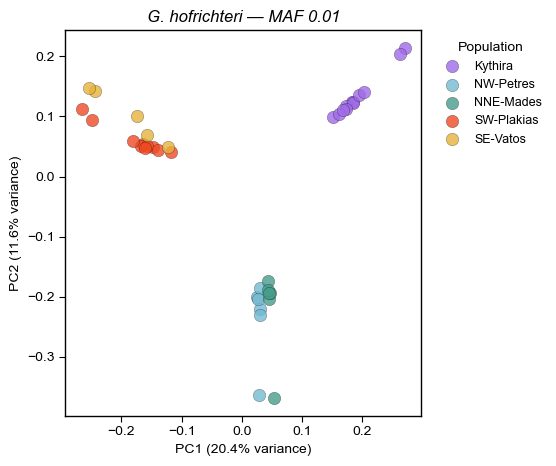

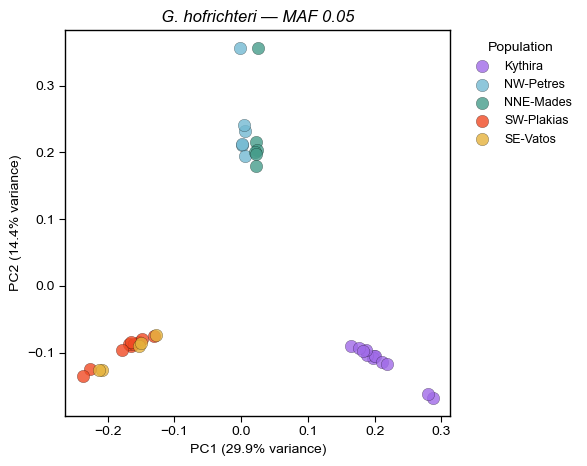

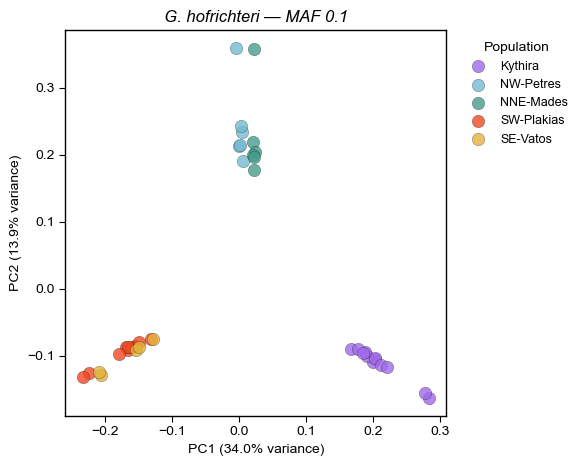

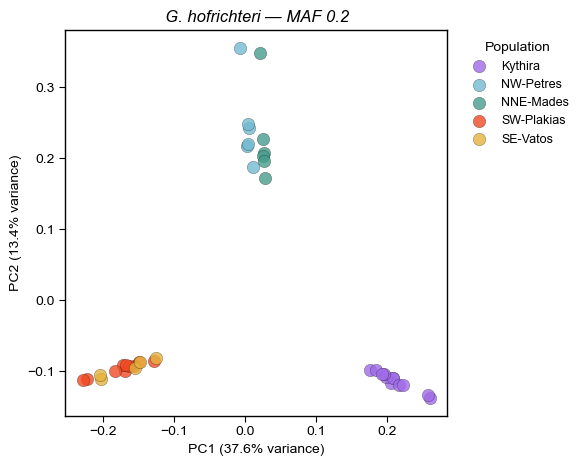

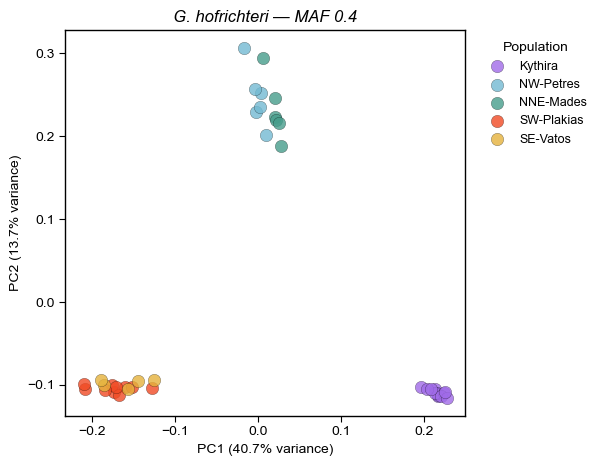

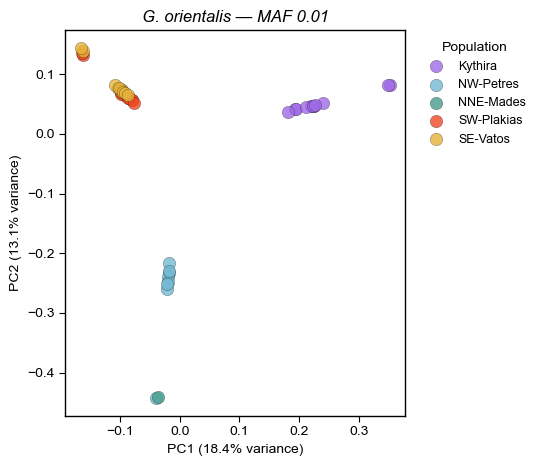

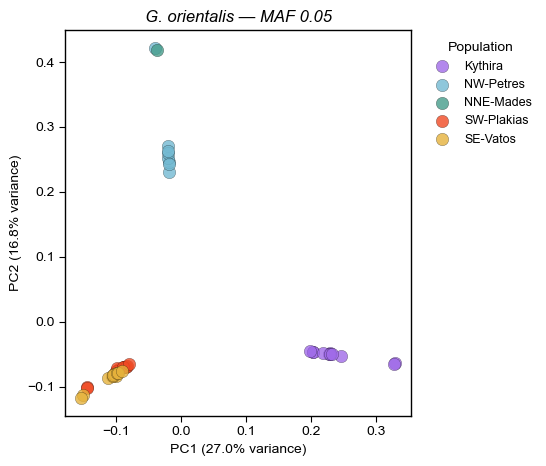

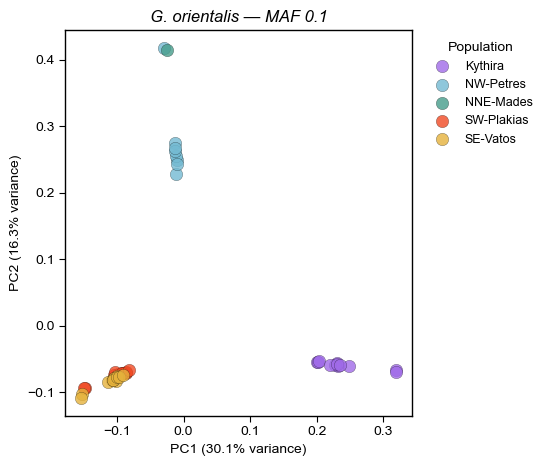

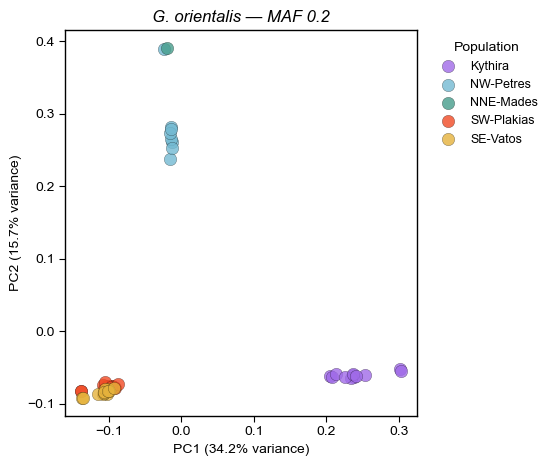

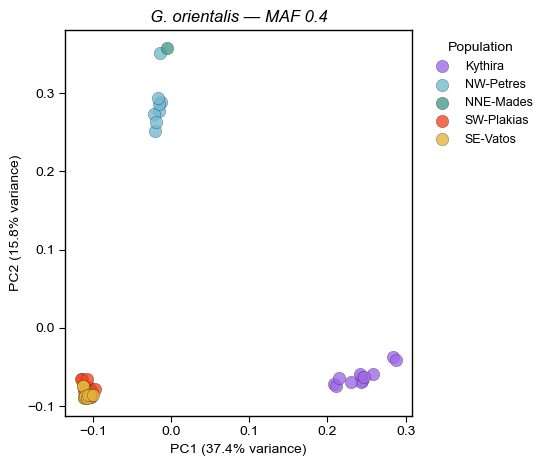

saved: /Users/maximilianwagner/Desktop/CretePopGenomics_local/results/pca/Crete_pca_plots_all_MAFs.pdf


In [80]:
from matplotlib.backends.backend_pdf import PdfPages

POP_COLORS = {
    "Kythira": "#A06BE8",
    "NW-Petres": "#73BAD2",
    "NNE-Mades": "#469D8B",
    "SW-Plakias": "#F04A24",
    "SE-Vatos": "#E5B23C",
}

POP_ORDER = ["Kythira", "NW-Petres", "NNE-Mades", "SW-Plakias", "SE-Vatos"]

SPECIES_LABELS = {
    "orientalis": "G. orientalis",
    "hofrichteri": "G. hofrichteri",
}

PCA_DIR = DATA / "snakemake" / "pca"
PCA_OUT = RESULTS / "pca"
PCA_OUT.mkdir(parents=True, exist_ok=True)

MAFS = ["0.01", "0.05", "0.1", "0.2", "0.4"]


def read_plink_eigenvec(path, species, maf):
    rows = []

    with open(path) as infile:
        for line in infile:
            line = line.strip()
            if not line or line.startswith("#FID"):
                continue

            parts = line.split()
            fid = parts[0]
            iid = parts[1]
            pcs = [float(x) for x in parts[2:]]

            location = iid.split("_")[-1]

            row = {
                "SPECIES": species,
                "MAF": maf,
                "LOCATION": location,
                "FID": fid,
                "IID": iid,
            }

            for i, pc in enumerate(pcs, start=1):
                row[f"PC{i}"] = pc

            rows.append(row)

    return pd.DataFrame(rows)


def read_plink_eigenval(path):
    vals = pd.read_csv(path, header=None)[0].astype(float).values
    return vals / vals.sum()


# Read all PCA files
all_pca = []

for species in ["hofrichteri", "orientalis"]:
    for maf in MAFS:
        eigenvec = PCA_DIR / f"{species}_variants.tif1.sft1.pass.snps.biallelic.pca.maf{maf}.eigenvec"
        eigenval = PCA_DIR / f"{species}_variants.tif1.sft1.pass.snps.biallelic.pca.maf{maf}.eigenval"

        if not eigenvec.exists():
            print(f"Skipping missing eigenvec: {eigenvec}")
            continue

        df = read_plink_eigenvec(eigenvec, species, maf)

        if eigenval.exists():
            var = read_plink_eigenval(eigenval)
            df["PC1_var"] = var[0]
            df["PC2_var"] = var[1]
        else:
            df["PC1_var"] = np.nan
            df["PC2_var"] = np.nan

        all_pca.append(df)

pca_all = pd.concat(all_pca, ignore_index=True)

# Export combined PCA table
combined_pca_out = PCA_OUT / "Crete_all_in_all_PCA.eigenvec.tsv"
pca_all.to_csv(combined_pca_out, sep="\t", index=False)
print(f"saved: {combined_pca_out}")


# Plot all PCA combinations into one PDF
pdf_filename = PCA_OUT / "Crete_pca_plots_all_MAFs.pdf"

with PdfPages(pdf_filename) as pdf:
    for (species, maf), group in pca_all.groupby(["SPECIES", "MAF"], sort=False):

        pc1_var = group["PC1_var"].iloc[0]
        pc2_var = group["PC2_var"].iloc[0]

        fig, ax = plt.subplots(figsize=(6, 5))

        for pop in POP_ORDER:
            sub = group[group["LOCATION"] == pop]

            if len(sub):
                ax.scatter(
                    sub["PC1"],
                    sub["PC2"],
                    label=pop,
                    color=POP_COLORS[pop],
                    s=80,
                    edgecolor="black",
                    linewidth=0.2,
                    alpha=0.8,
                )

        if np.isfinite(pc1_var):
            ax.set_xlabel(f"PC1 ({pc1_var*100:.1f}% variance)", fontsize=10)
            ax.set_ylabel(f"PC2 ({pc2_var*100:.1f}% variance)", fontsize=10)
        else:
            ax.set_xlabel("PC1", fontsize=12)
            ax.set_ylabel("PC2", fontsize=12)

        ax.tick_params(
            axis="both",
            which="major",
            length=4,
            width=0.8,
            labelsize=10
        )

        ax.set_title(
            f"{SPECIES_LABELS[species]} — MAF {maf}",
            fontsize=12,
            fontstyle="italic",
        )
        ax.set_aspect("equal", adjustable="box")

        ax.legend(
            title="Population",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            frameon=False,
            fontsize=9,
            title_fontsize=10,
        )

        for spine in ax.spines.values():
            spine.set_linewidth(1)

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.show()
        plt.close(fig)

print(f"saved: {pdf_filename}")

## 6. ADMIXTURE plots


orientalis 0 Q files
hofrichteri 2 Q files
saved: /Users/maximilianwagner/Desktop/CretePopGenomics_local/results/figures/ADMIXTURE_hofrichteri_hofrichteri_variants.tif1.sft1.pass.snps.biallelic.2.png
saved: /Users/maximilianwagner/Desktop/CretePopGenomics_local/results/figures/ADMIXTURE_hofrichteri_hofrichteri_variants.tif1.sft1.pass.snps.biallelic.2.pdf


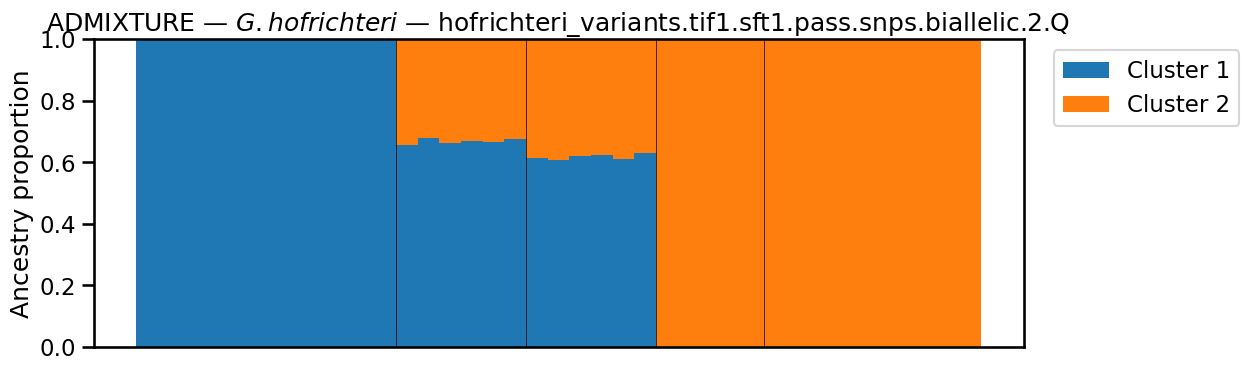

saved: /Users/maximilianwagner/Desktop/CretePopGenomics_local/results/figures/ADMIXTURE_hofrichteri_hofrichteri_variants.tif1.sft1.pass.snps.biallelic.3.png
saved: /Users/maximilianwagner/Desktop/CretePopGenomics_local/results/figures/ADMIXTURE_hofrichteri_hofrichteri_variants.tif1.sft1.pass.snps.biallelic.3.pdf


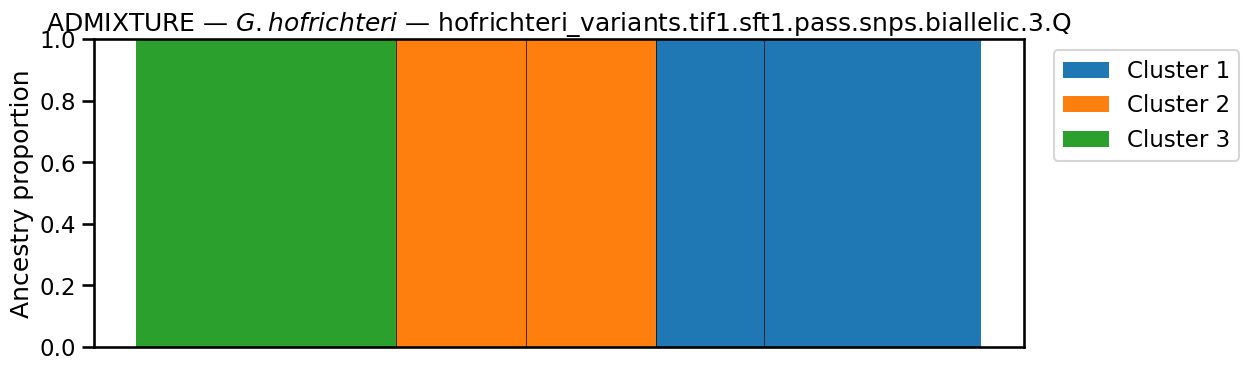

In [11]:
def find_admixture_q(species):
    return sorted((SNAKEMAKE / "admixture").glob(f"*{species}_{SNP_SUFFIX}*.Q"))


def read_fam_order(species):
    fam_candidates = sorted((SNAKEMAKE / "admixture").glob(f"*{species}_{SNP_SUFFIX}*.fam"))
    if fam_candidates:
        fam = pd.read_csv(fam_candidates[0], sep=r"\s+", header=None)
        return fam[1].astype(str).tolist()
    return species_popmap(species, no_outgroup=True)["sample"].tolist()


def plot_admixture(species, q_file):
    q = pd.read_csv(q_file, sep=r"\s+", header=None)
    samples = read_fam_order(species)
    if len(samples) != len(q):
        warnings.warn(f"Sample count mismatch for {q_file.name}. Using row numbers.")
        samples = [f"sample_{i+1}" for i in range(len(q))]
    q.index = samples
    meta = pd.DataFrame([parse_sample(s) for s in samples]).set_index("sample")
    q = q.join(meta)
    q["population_order"] = pd.Categorical(q["population"], categories=POP_ORDER, ordered=True)
    q = q.sort_values(["population_order"])
    comp_cols = [c for c in q.columns if isinstance(c, int)]
    fig, ax = plt.subplots(figsize=(12, 4))
    bottom = np.zeros(len(q))
    for c in comp_cols:
        ax.bar(range(len(q)), q[c], bottom=bottom, width=1.0, label=f"Cluster {c+1}")
        bottom += q[c].to_numpy()
    ax.set_xticks([])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Ancestry proportion")
    ax.set_title(f"ADMIXTURE — {SPECIES_LABELS.get(species, species)} — {q_file.name}")
    pops = q["population"].tolist()
    for i in range(1, len(pops)):
        if pops[i] != pops[i-1]:
            ax.axvline(i - 0.5, color="black", lw=0.5)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    savefig(f"ADMIXTURE_{species}_{q_file.stem}")
    plt.show()

for sp in SPECIES:
    q_files = find_admixture_q(sp)
    print(sp, len(q_files), "Q files")
    for qf in q_files:
        plot_admixture(sp, qf)


## 7. Distance matrices and SplitsTree export

This converts PLINK square distance matrices into PHYLIP format for SplitsTree / NeighborNet.

For best results, download both `*.dist` and `*.dist.id` files from the cluster.


saved SplitsTree matrix: orientalis_maf0.1.distance_matrix.phy


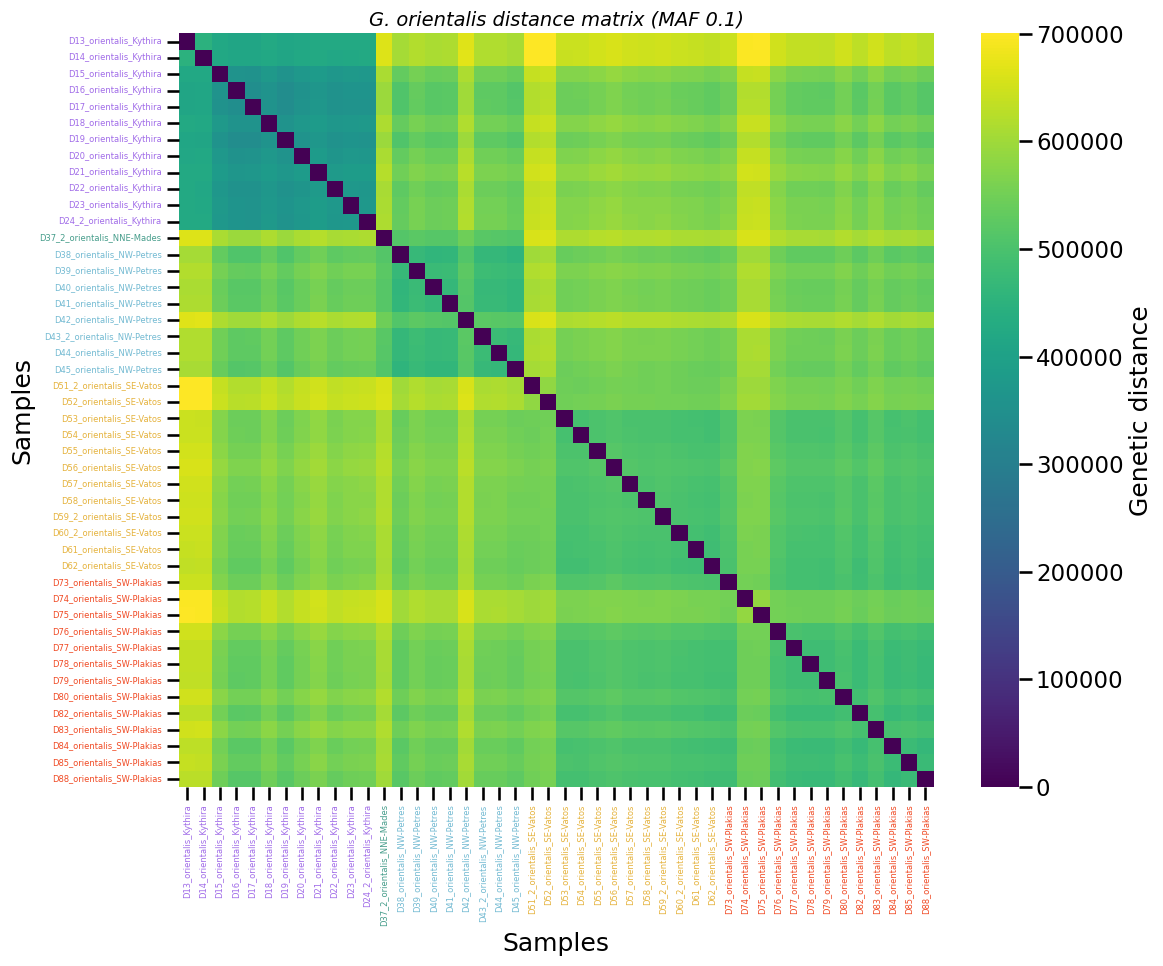

/Users/maximilianwagner/mamba/lib/python3.14/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/Users/maximilianwagner/mamba/lib/python3.14/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


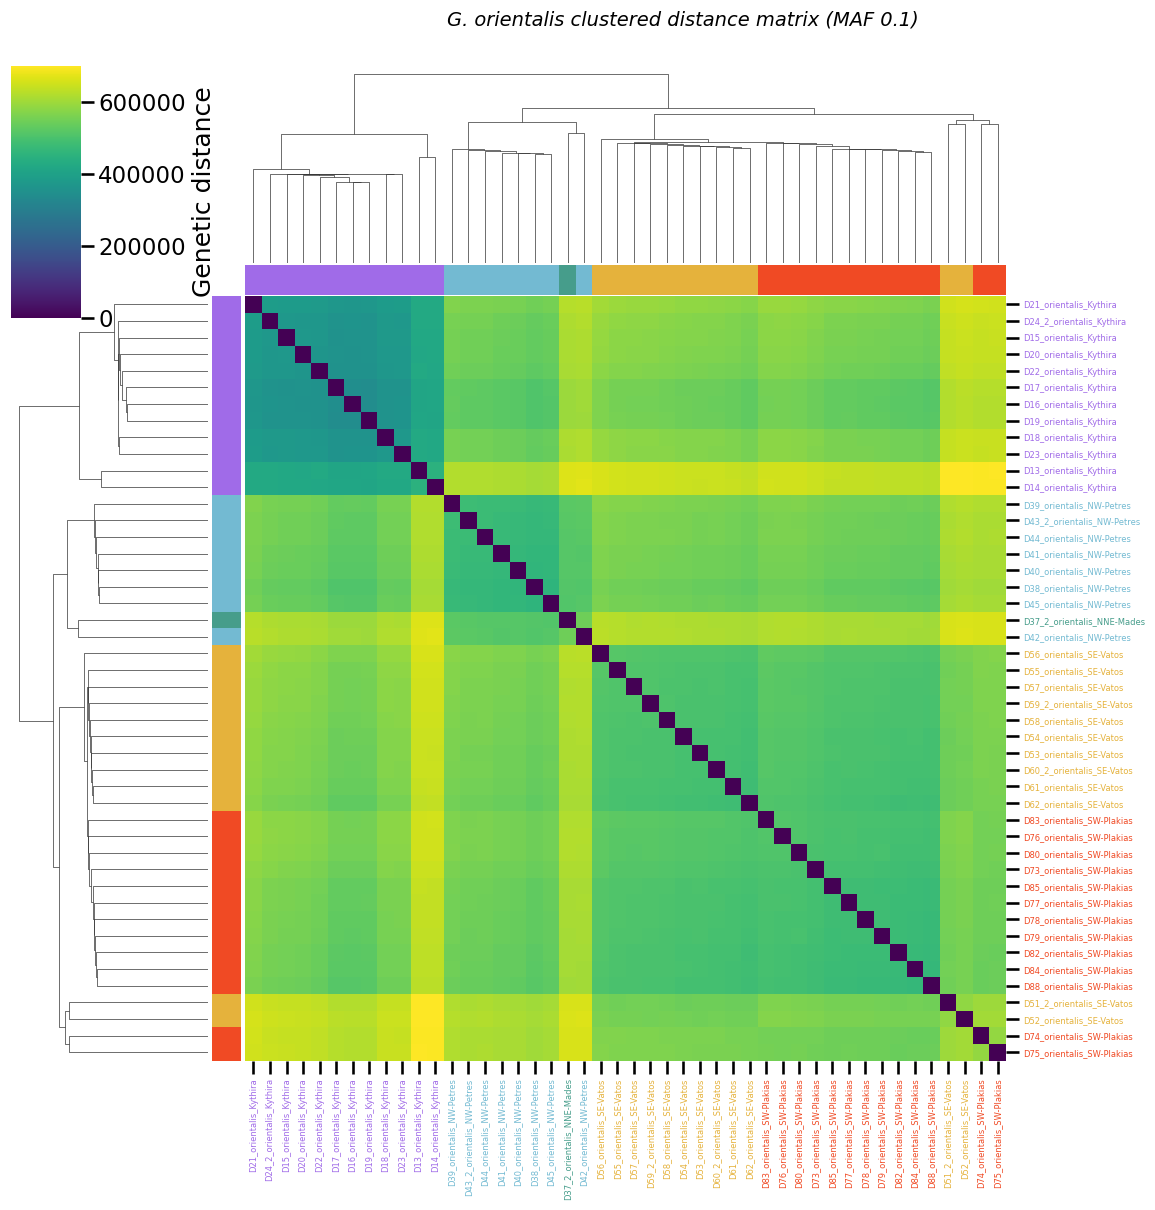

saved SplitsTree matrix: orientalis_maf0.4.distance_matrix.phy


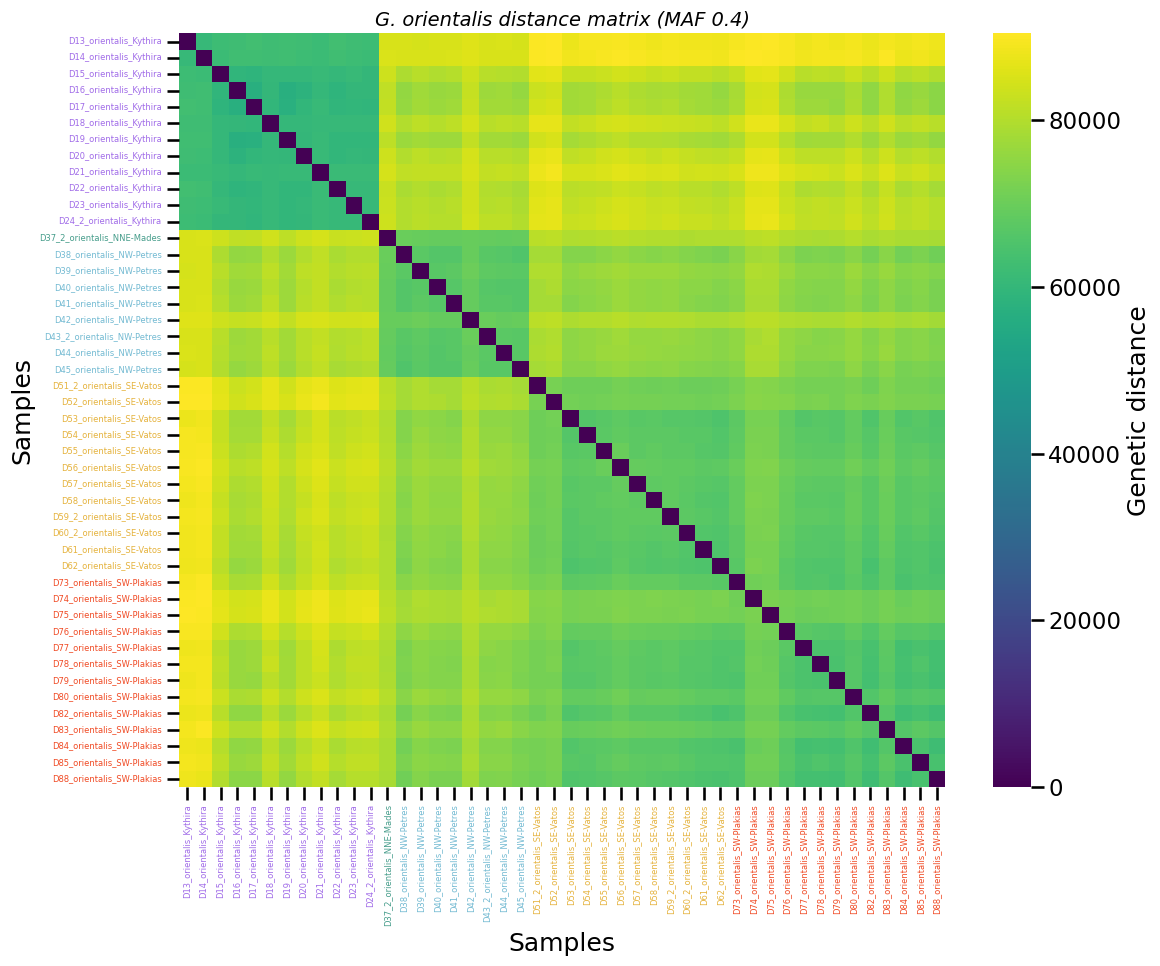

/Users/maximilianwagner/mamba/lib/python3.14/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/Users/maximilianwagner/mamba/lib/python3.14/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


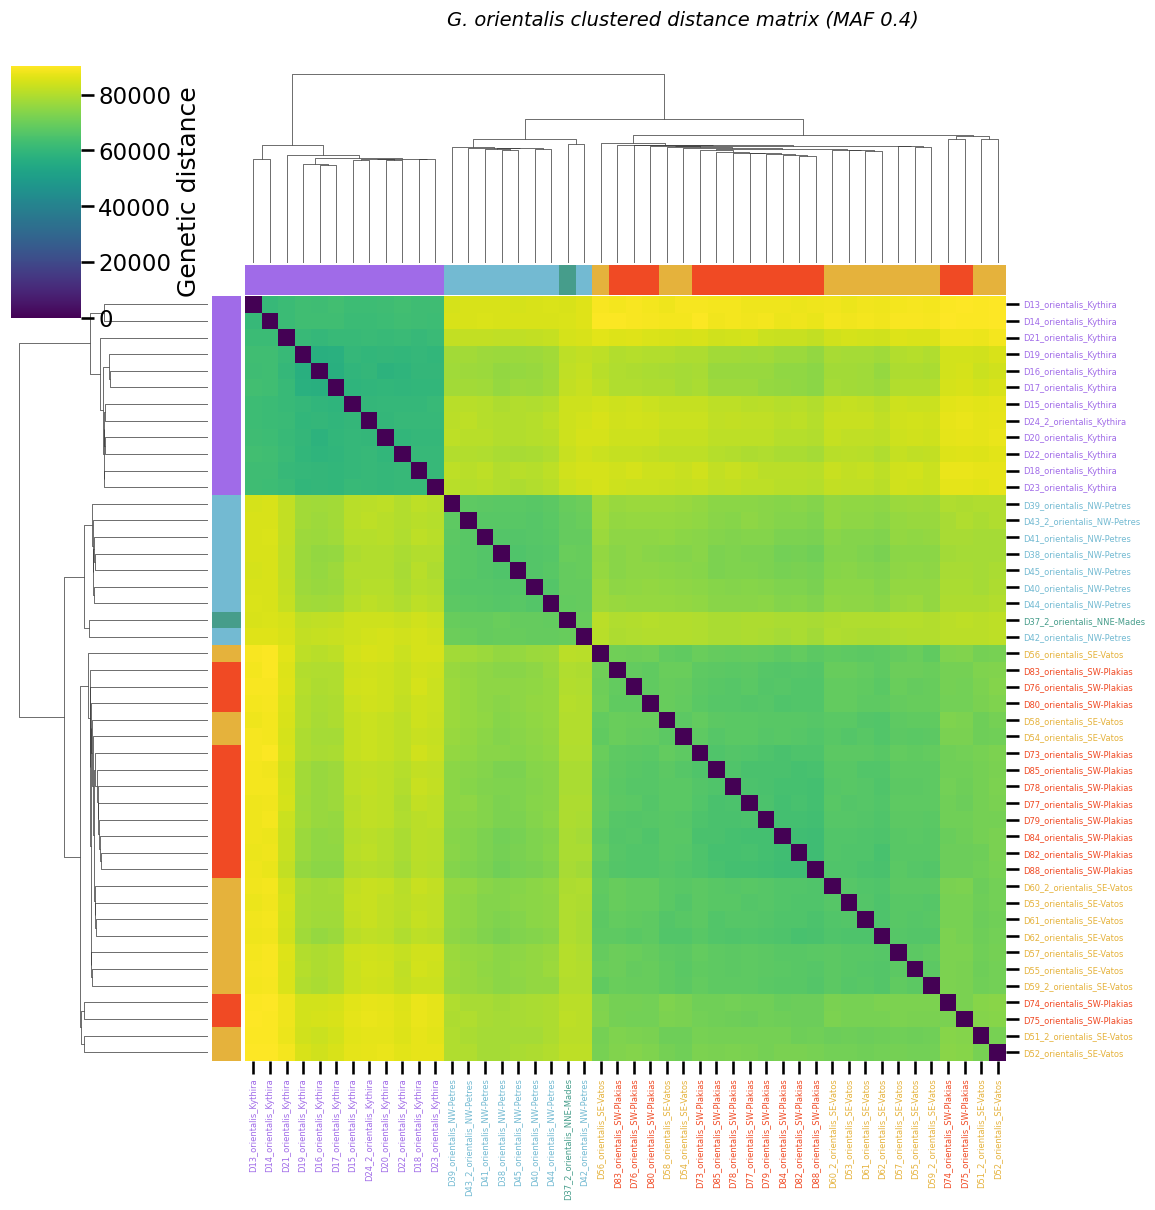

saved SplitsTree matrix: hofrichteri_maf0.1.distance_matrix.phy


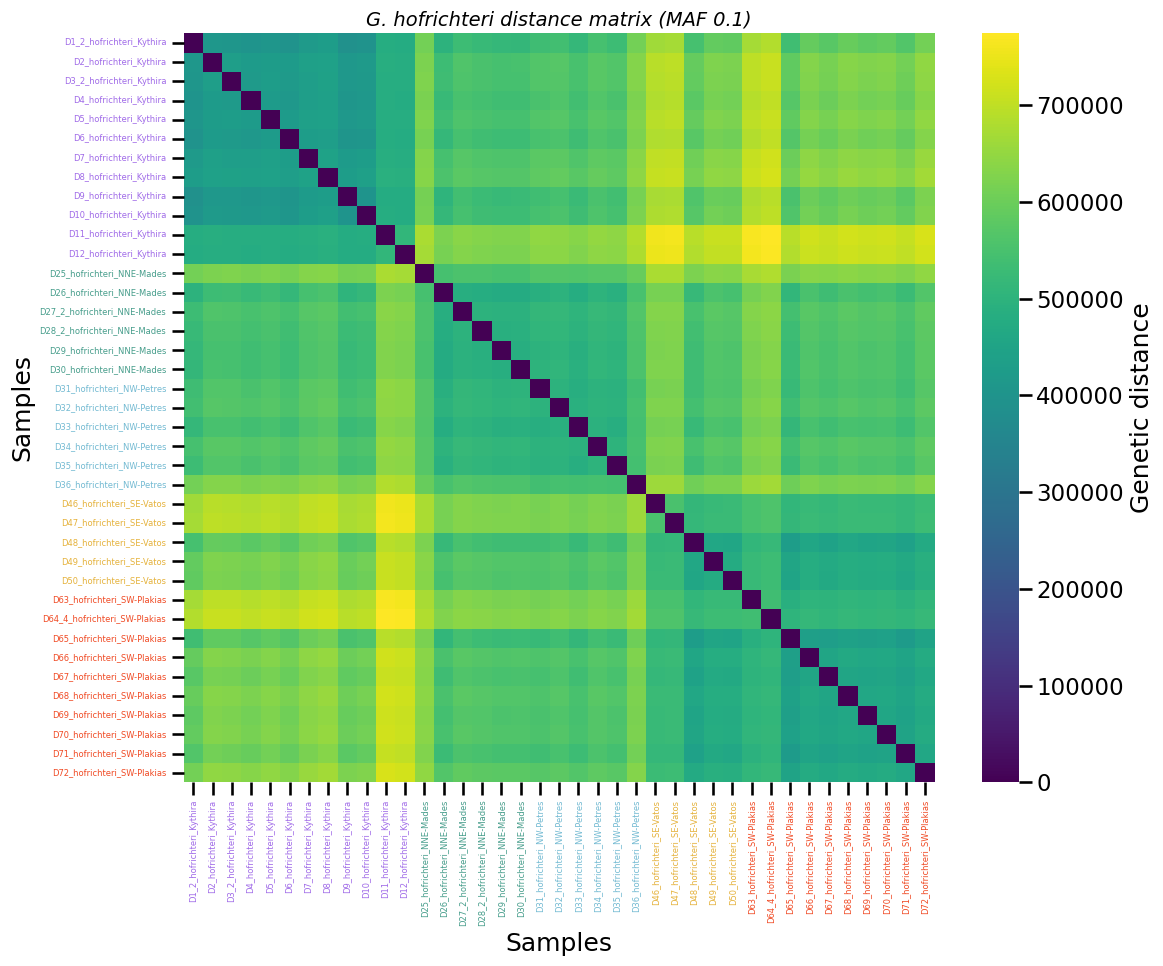

/Users/maximilianwagner/mamba/lib/python3.14/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/Users/maximilianwagner/mamba/lib/python3.14/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


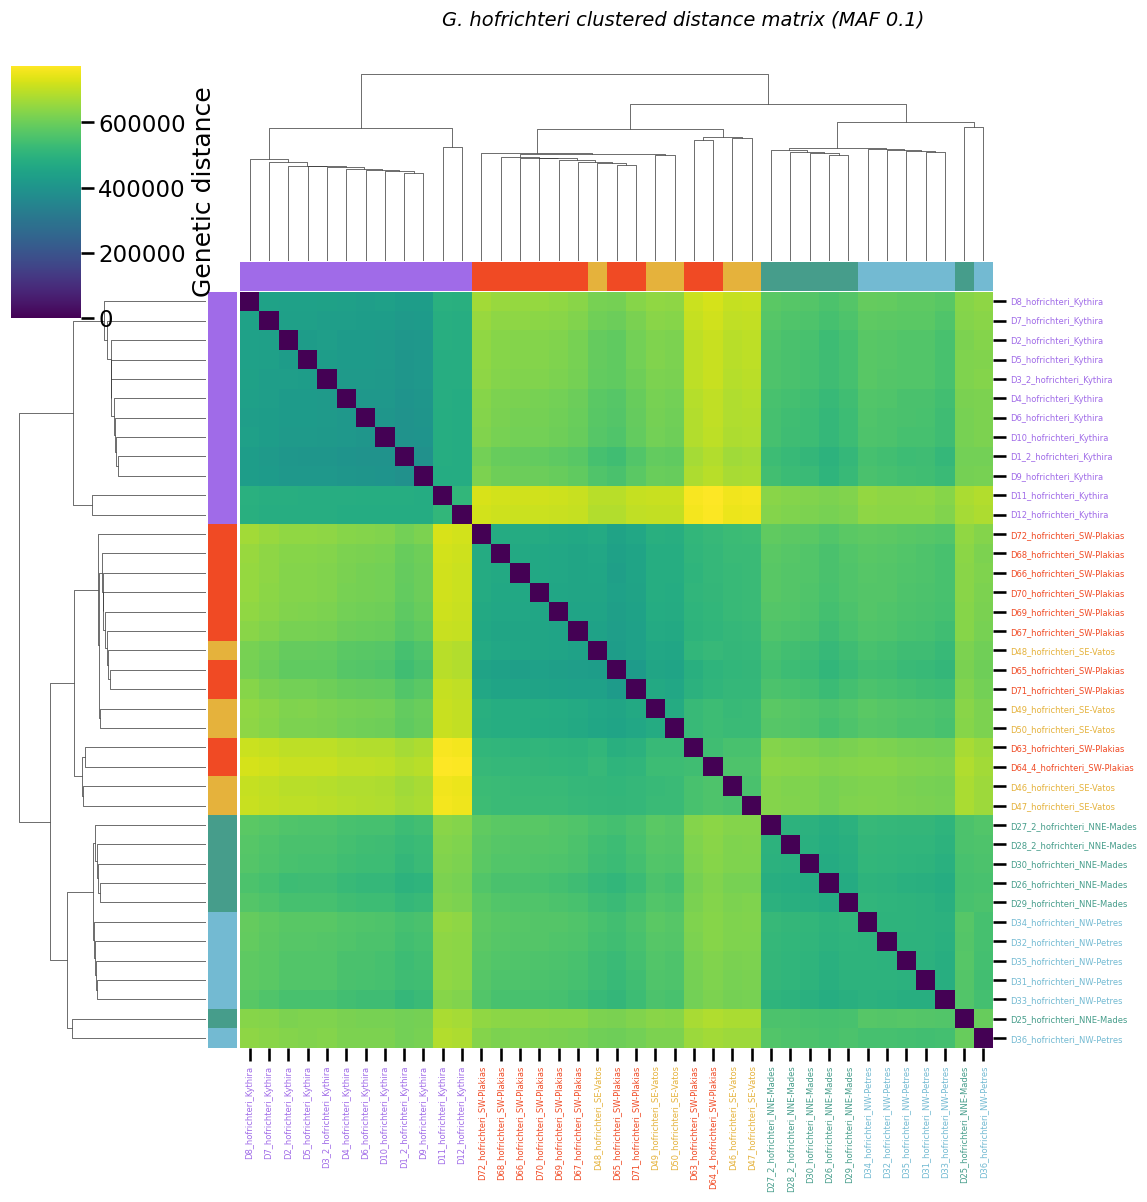

saved SplitsTree matrix: hofrichteri_maf0.4.distance_matrix.phy


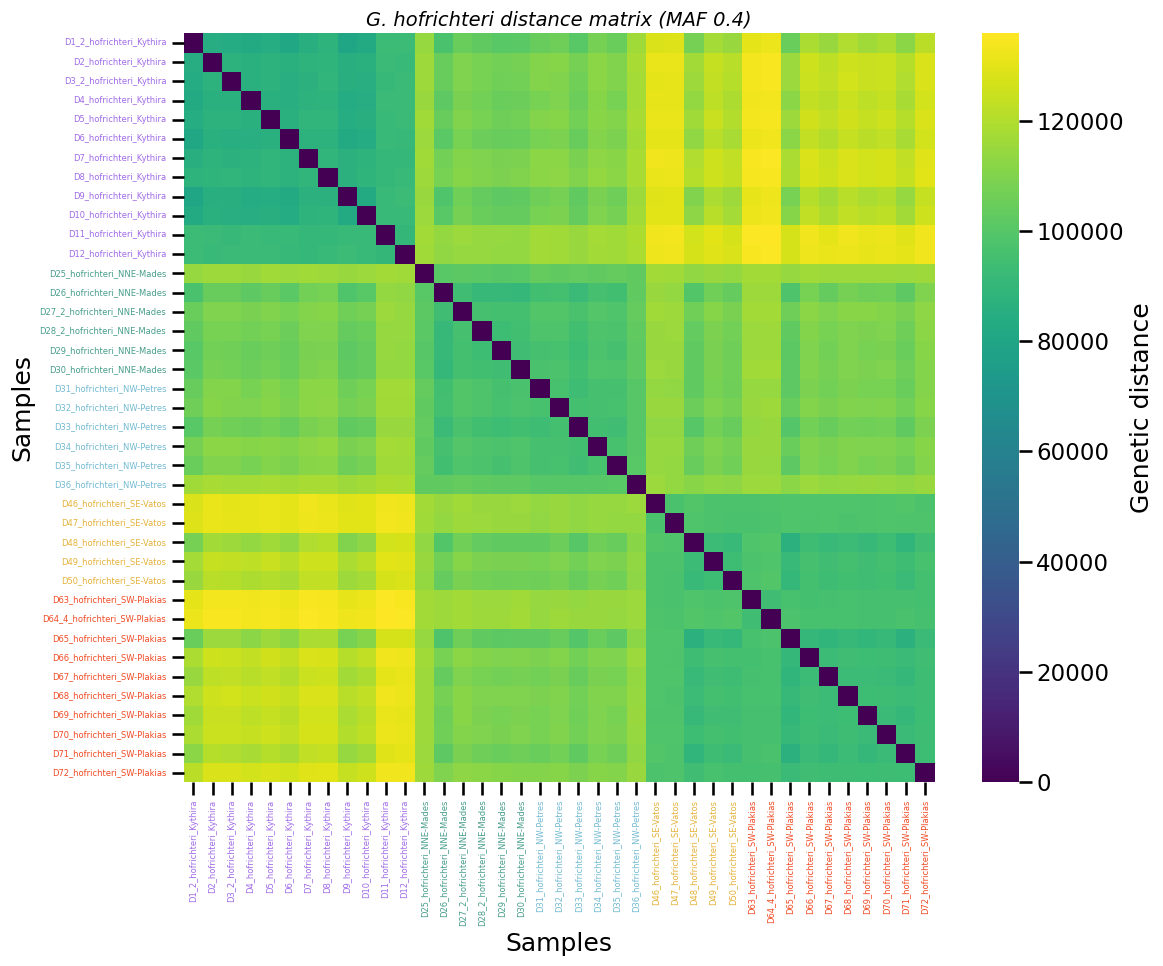

/Users/maximilianwagner/mamba/lib/python3.14/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/Users/maximilianwagner/mamba/lib/python3.14/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


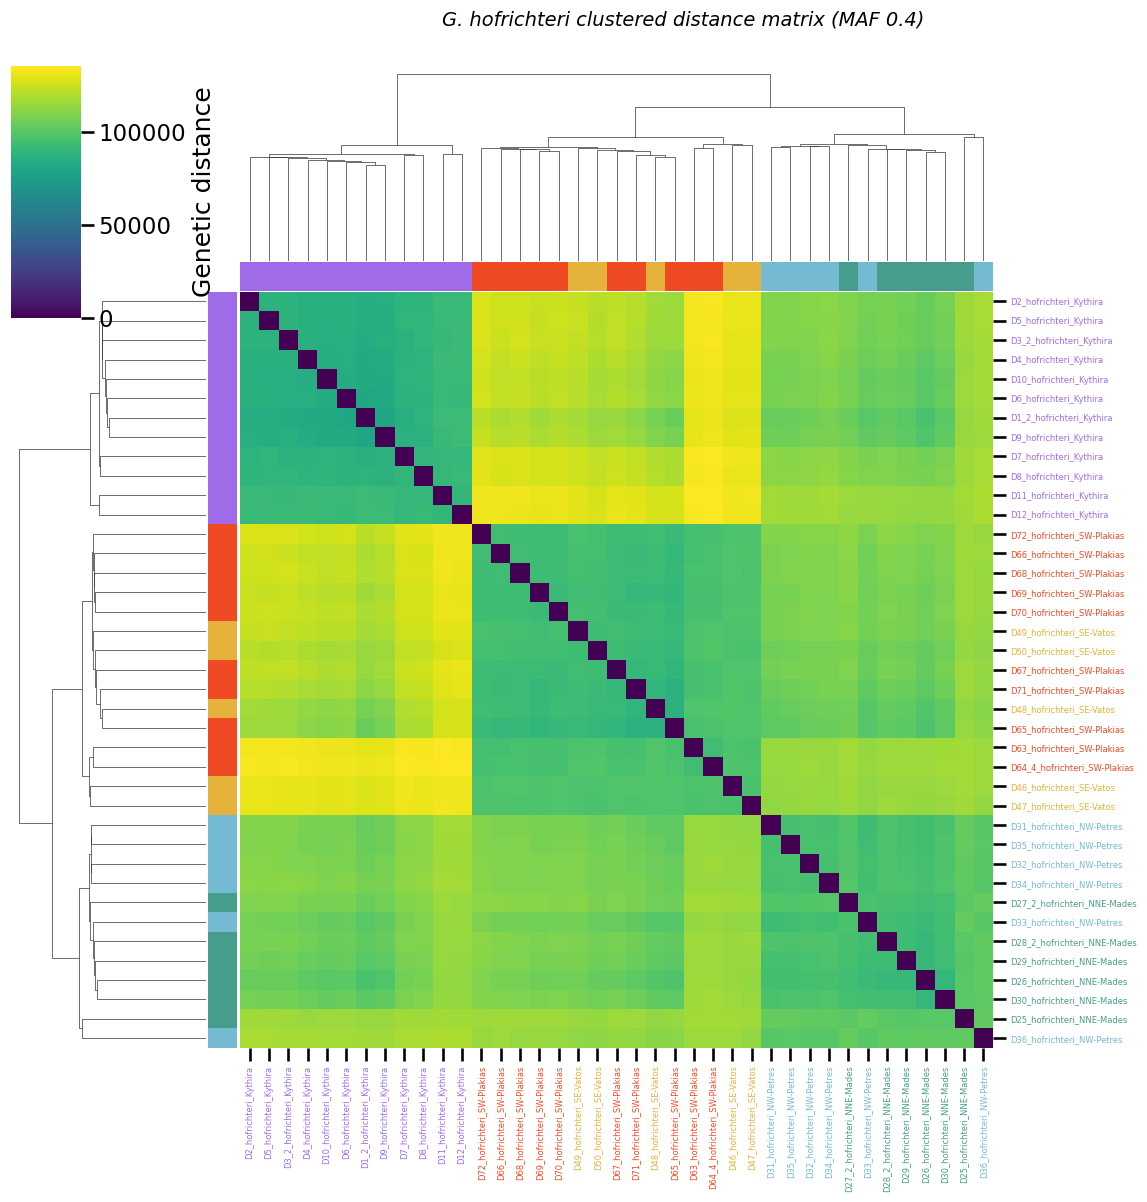

In [53]:
# =============================================================================
# Appendix: Distance matrices and SplitsTree export
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DIST_DIR = DATA / "snakemake" / "distance"
SPLITSTREE_DIR = RESULTS / "splitstree"
SPLITSTREE_DIR.mkdir(parents=True, exist_ok=True)

DIST_FIG_DIR = FIGURES / "distance_matrices"
DIST_FIG_DIR.mkdir(parents=True, exist_ok=True)

DIST_MAFS = ["0.1", "0.4"]


def read_distance_matrix(dist_file, id_file):
    matrix = np.loadtxt(dist_file)

    with open(id_file) as f:
        sample_names = [line.split()[0].strip() for line in f if line.strip()]

    if len(sample_names) != matrix.shape[0]:
        raise ValueError(
            f"Sample names ({len(sample_names)}) do not match matrix "
            f"dimensions ({matrix.shape[0]} x {matrix.shape[1]})"
        )

    return pd.DataFrame(
        matrix,
        index=sample_names,
        columns=sample_names
    )


def write_phylip_distance_matrix(df, outfile):
    outfile = Path(outfile)

    with open(outfile, "w") as out:
        out.write(f"{df.shape[0]}\n")

        for sample in df.index:
            values = " ".join(
                f"{x:.8f}"
                for x in df.loc[sample].values
            )

            out.write(f"{sample} {values}\n")


def sample_to_population(sample):
    for pop in POP_ORDER:
        if pop in sample:
            return pop
    return "Unknown"


for species in SPECIES:
    for maf in DIST_MAFS:

        prefix = (
            f"{species}_variants.tif1.sft1.pass.snps."
            f"biallelic_maf{maf}.distance_matrix"
        )

        dist_file = DIST_DIR / f"{prefix}.dist"
        id_file = DIST_DIR / f"{prefix}.dist.id"

        if not dist_file.exists():
            print(f"missing: {dist_file}")
            continue

        distance_matrix = read_distance_matrix(
            dist_file,
            id_file
        )

        # ---------------------------------------------------------------------
        # Export labelled matrices
        # ---------------------------------------------------------------------

        distance_matrix.to_csv(
            SPLITSTREE_DIR / f"{species}_maf{maf}.distance_matrix.tsv",
            sep="\t"
        )

        write_phylip_distance_matrix(
            distance_matrix,
            SPLITSTREE_DIR / f"{species}_maf{maf}.distance_matrix.phy"
        )

        print(
            f"saved SplitsTree matrix: "
            f"{species}_maf{maf}.distance_matrix.phy"
        )

        # ---------------------------------------------------------------------
        # Standard heatmap
        # ---------------------------------------------------------------------

        fig, ax = plt.subplots(figsize=(12, 10))

        sns.heatmap(
            distance_matrix,
            cmap="viridis",
            xticklabels=distance_matrix.columns,
            yticklabels=distance_matrix.index,
            cbar_kws={"label": "Genetic distance"},
            ax=ax,
        )

        ax.set_title(
            f"{SPECIES_LABELS[species]} distance matrix (MAF {maf})",
            fontsize=14,
            fontstyle="italic",
        )

        ax.set_xlabel("Samples")
        ax.set_ylabel("Samples")

        plt.xticks(rotation=90, fontsize=6)
        plt.yticks(rotation=0, fontsize=6)

        for label in ax.get_xticklabels():
            sample = label.get_text()
            pop = sample_to_population(sample)
            if pop in POP_COLORS:
                label.set_color(POP_COLORS[pop])

        for label in ax.get_yticklabels():
            sample = label.get_text()
            pop = sample_to_population(sample)
            if pop in POP_COLORS:
                label.set_color(POP_COLORS[pop])

        plt.tight_layout()

        fig.savefig(
            DIST_FIG_DIR /
            f"DistanceMatrix_{species}_maf{maf}.pdf",
            bbox_inches="tight"
        )

        plt.show()

        # ---------------------------------------------------------------------
        # Clustered heatmap
        # ---------------------------------------------------------------------

        row_colors = [
            POP_COLORS.get(
                sample_to_population(sample),
                "grey"
            )
            for sample in distance_matrix.index
        ]

        cg = sns.clustermap(
            distance_matrix,
            cmap="viridis",
            figsize=(14, 14),
            row_colors=row_colors,
            col_colors=row_colors,
            xticklabels=True,
            yticklabels=True,
            method="average",
            metric="euclidean",
            cbar_kws={"label": "Genetic distance"},
        )

        cg.fig.suptitle(
            f"{SPECIES_LABELS[species]} clustered distance matrix (MAF {maf})",
            fontsize=14,
            fontstyle="italic",
            y=1.02,
        )

        plt.setp(
            cg.ax_heatmap.get_xticklabels(),
            rotation=90,
            fontsize=6
        )

        plt.setp(
            cg.ax_heatmap.get_yticklabels(),
            rotation=0,
            fontsize=6
        )

        for label in cg.ax_heatmap.get_xticklabels():
            sample = label.get_text()
            pop = sample_to_population(sample)
            if pop in POP_COLORS:
                label.set_color(POP_COLORS[pop])

        for label in cg.ax_heatmap.get_yticklabels():
            sample = label.get_text()
            pop = sample_to_population(sample)
            if pop in POP_COLORS:
                label.set_color(POP_COLORS[pop])

        cg.fig.savefig(
            DIST_FIG_DIR /
            f"ClusteredDistanceMatrix_{species}_maf{maf}.pdf",
            bbox_inches="tight"
        )

        plt.show()

## 8. Windowed π, dXY, FST, and dA


In [54]:
def popgen_path(species):
    return SNAKEMAKE / "popgenwindows" / f"{species}_{ALLSITES_SUFFIX}.{WINDOW_LABEL}.Fst.Dxy.pi.dA.csv.gz"


def read_popgen(species):
    df = pd.read_csv(require_file(popgen_path(species)), sep="	", compression="gzip")
    df["species"] = species
    return df

popgen = {sp: read_popgen(sp) for sp in SPECIES}
for sp, df in popgen.items():
    print(sp, df.shape, df.columns[:8].tolist())


orientalis (29039, 41) ['scaffold', 'start', 'end', 'mid', 'sites', 'pi_Kythira', 'pi_NNE-Mades', 'pi_NW-Petres']
hofrichteri (29039, 41) ['scaffold', 'start', 'end', 'mid', 'sites', 'pi_Kythira', 'pi_NNE-Mades', 'pi_NW-Petres']


In [55]:
def summarize_window_stats(df, species):
    rows = []
    for prefix in ["pi", "dxy", "Fst", "dA"]:
        for col in pair_columns(df, prefix):
            vals = pd.to_numeric(df[col], errors="coerce")
            rows.append({
                "species": species, "stat": prefix, "comparison": col.replace(prefix + "_", ""),
                "mean": vals.mean(), "median": vals.median(), "sd": vals.std(), "n_windows": vals.notna().sum()
            })
    return pd.DataFrame(rows)

window_summary = pd.concat([summarize_window_stats(df, sp) for sp, df in popgen.items()], ignore_index=True)
window_summary.to_csv(TABLES / "windowed_population_genomic_summary.tsv", sep="	", index=False)
window_summary.head(20)


,species,stat,comparison,mean,median,sd,n_windows
0,orientalis,pi,Kythira,0.002891,0.0029,0.000870,28268
1,orientalis,pi,NNE-Mades,0.004403,0.0046,0.001873,28252
2,orientalis,pi,NW-Petres,0.003397,0.0035,0.001113,28269
3,orientalis,pi,SE-Vatos,0.003726,0.0039,0.001217,28270
4,orientalis,pi,SW-Plakias,0.003615,0.0038,0.001191,28270
5,orientalis,dxy,Kythira_NNE-Mades,0.004099,0.0042,0.001220,28250
6,orientalis,dxy,Kythira_NW-Petres,0.003548,0.0036,0.000994,28268
7,orientalis,dxy,Kythira_SE-Vatos,0.003725,0.0039,0.001036,28268
8,orientalis,dxy,Kythira_SW-Plakias,0.003651,0.0038,0.001022,28268
9,orientalis,dxy,NNE-Mades_NW-Petres,0.003829,0.0040,0.001302,28252


saved: /Users/maximilianwagner/Desktop/CretePopGenomics_local/results/figures/popgenwindows/Nucleotide_diversity_Crete.pdf


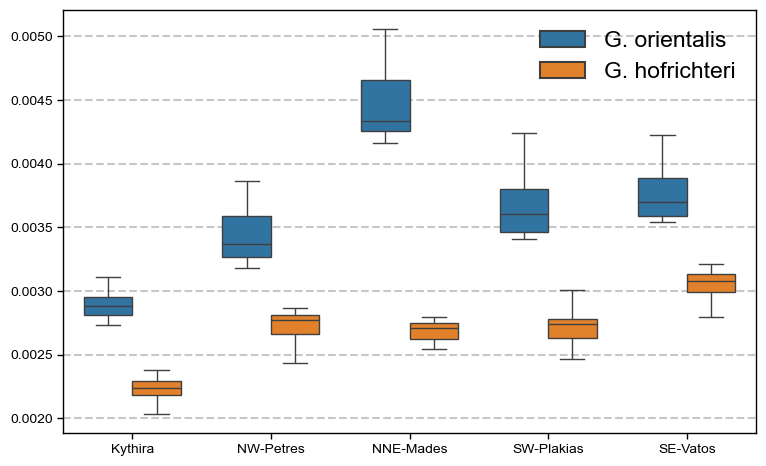

saved: /Users/maximilianwagner/Desktop/CretePopGenomics_local/results/figures/popgenwindows/Comparative_pairwise_FST_matrix.pdf


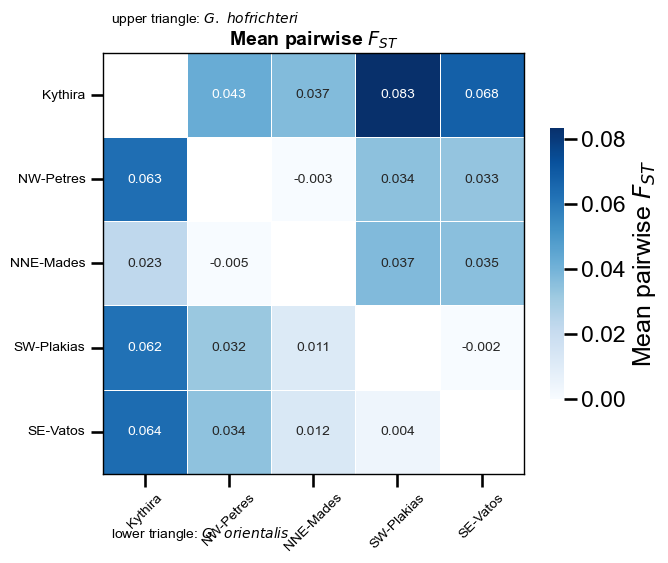

,Kythira,NW-Petres,NNE-Mades,SW-Plakias,SE-Vatos
Kythira,NaN,0.042543,0.036985,0.083219,0.067881
NW-Petres,0.063093,NaN,-0.002569,0.034474,0.033283
NNE-Mades,0.022728,-0.004971,NaN,0.037262,0.035296
SW-Plakias,0.062292,0.032121,0.011086,NaN,-0.001770
SE-Vatos,0.063971,0.034425,0.012375,0.004204,NaN


In [85]:
# =============================================================================
# Nucleotide diversity pi and comparative FST matrix
# =============================================================================

POP_ORDER = ["Kythira", "NW-Petres", "NNE-Mades", "SW-Plakias", "SE-Vatos"]

POPGEN_FIG_DIR = FIGURES / "popgenwindows"
POPGEN_FIG_DIR.mkdir(parents=True, exist_ok=True)

POPGEN_TABLE_DIR = TABLES / "popgenwindows"
POPGEN_TABLE_DIR.mkdir(parents=True, exist_ok=True)


def clean_pair_name(col, prefix):
    return col.replace(prefix + "_", "")


def split_pair(pair):
    parts = pair.split("_")
    return parts[0], parts[1]


def mean_window_stat_matrix(df, prefix, pop_order=POP_ORDER):
    cols = [c for c in df.columns if c.startswith(prefix + "_")]

    mat = pd.DataFrame(
        np.nan,
        index=pop_order,
        columns=pop_order,
        dtype=float,
    )

    means = df[cols].apply(pd.to_numeric, errors="coerce").mean()

    for col in cols:
        pair = clean_pair_name(col, prefix)
        pop1, pop2 = split_pair(pair)

        if pop1 in pop_order and pop2 in pop_order:
            val = means[col]
            mat.loc[pop1, pop2] = val
            mat.loc[pop2, pop1] = val

    return mat


# =============================================================================
# Pi boxplot: genome-wide nucleotide diversity per population and species
# =============================================================================

pi_records = []

for species, df in popgen.items():

    pi_cols = [c for c in df.columns if c.startswith("pi_")]

    tmp = df[["scaffold"] + pi_cols].copy()

    for col in pi_cols:
        tmp[col] = pd.to_numeric(tmp[col], errors="coerce")

    grouped = tmp.groupby("scaffold")[pi_cols].mean().reset_index()

    melted = grouped.melt(
        id_vars="scaffold",
        var_name="Location",
        value_name="Pi",
    )

    melted["Location"] = melted["Location"].str.replace("pi_", "", regex=False)
    melted["Species"] = SPECIES_LABELS[species]

    pi_records.append(melted)

pi_df = pd.concat(pi_records, ignore_index=True)
pi_df["Location"] = pd.Categorical(
    pi_df["Location"],
    categories=POP_ORDER,
    ordered=True,
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=pi_df,
    x="Location",
    y="Pi",
    hue="Species",
    order=POP_ORDER,
    width=0.7,
    showfliers=False,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel(r"Nucleotide diversity ($\pi$)", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(
    axis="x",
    rotation=0,
    labelsize=10,
    length=4,
    width=1
)

ax.tick_params(
    axis="y",
    rotation=0,
    labelsize=10,
    length=4,
    width=1
)

ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.7,
)

ax.legend(
    title=None,
    frameon=False,
    loc="upper right",
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)

plt.tight_layout()

pi_out = POPGEN_FIG_DIR / "Nucleotide_diversity_Crete.pdf"
fig.savefig(pi_out, bbox_inches="tight")
print(f"saved: {pi_out}")

plt.show()


# =============================================================================
# Comparative pairwise FST matrix
# Lower triangle: G. orientalis
# Upper triangle: G. hofrichteri
# =============================================================================

fst_orientalis = mean_window_stat_matrix(
    popgen["orientalis"],
    "Fst",
    pop_order=POP_ORDER,
)

fst_hofrichteri = mean_window_stat_matrix(
    popgen["hofrichteri"],
    "Fst",
    pop_order=POP_ORDER,
)

comparative_fst = pd.DataFrame(
    np.nan,
    index=POP_ORDER,
    columns=POP_ORDER,
    dtype=float,
)

for i, pop_i in enumerate(POP_ORDER):
    for j, pop_j in enumerate(POP_ORDER):

        if i > j:
            comparative_fst.loc[pop_i, pop_j] = fst_orientalis.loc[pop_i, pop_j]

        elif i < j:
            comparative_fst.loc[pop_i, pop_j] = fst_hofrichteri.loc[pop_i, pop_j]

        else:
            comparative_fst.loc[pop_i, pop_j] = np.nan

comparative_fst.to_csv(
    POPGEN_TABLE_DIR / "comparative_pairwise_FST_orientalis_lower_hofrichteri_upper.tsv",
    sep="\t",
)

fig, ax = plt.subplots(figsize=(7, 6))

mask_diag = np.eye(len(POP_ORDER), dtype=bool)

sns.heatmap(
    comparative_fst,
    mask=mask_diag,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5,
    square=True,
    vmin=0,
    vmax=np.nanmax(comparative_fst.values),
    cbar_kws={
        "label": r"Mean pairwise $F_{ST}$",
        "shrink": 0.6,
    },
    annot_kws={
        "size": 10,
    },
    ax=ax,
)

ax.set_title(
    r"Mean pairwise $F_{ST}$",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=10)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)

# Add species labels
ax.text(
    0.02,
    1.06,
    r"upper triangle: $G.\ hofrichteri$",
    transform=ax.transAxes,
    fontsize=10,
    ha="left",
    va="bottom",
)

ax.text(
    0.02,
    -0.12,
    r"lower triangle: $G.\ orientalis$",
    transform=ax.transAxes,
    fontsize=10,
    ha="left",
    va="top",
)

plt.tight_layout()

fst_out = POPGEN_FIG_DIR / "Comparative_pairwise_FST_matrix.pdf"
fig.savefig(fst_out, bbox_inches="tight")
print(f"saved: {fst_out}")

plt.show()

comparative_fst

## 9. Tajima's D


In [86]:
def tajima_path(species):
    return SNAKEMAKE / "TajimasD" / f"{species}_{ALLSITES_SUFFIX}.{WINDOW_LABEL}.D.tsv.gz"


def read_tajima(species):
    df = pd.read_csv(require_file(tajima_path(species)), sep="	", compression="gzip")
    df["species"] = species
    return df

tajima = {sp: read_tajima(sp) for sp in SPECIES}
for sp, df in tajima.items():
    print(sp, df.shape, df.columns.tolist()[:10])


orientalis (29039, 9) ['scaffold', 'start', 'end', 'Kythira_TajimaD', 'NNE_Mades_TajimaD', 'NW_Petres_TajimaD', 'SE_Vatos_TajimaD', 'SW_Plakias_TajimaD', 'species']
hofrichteri (29039, 9) ['scaffold', 'start', 'end', 'Kythira_TajimaD', 'NNE_Mades_TajimaD', 'NW_Petres_TajimaD', 'SE_Vatos_TajimaD', 'SW_Plakias_TajimaD', 'species']


In [87]:
def tajima_cols(df):
    return [c for c in df.columns if c.startswith("D_") or c in POP_ORDER]

records = []
for sp, df in tajima.items():
    for col in tajima_cols(df):
        if col in ["scaffold", "start", "end", "mid", "species"]:
            continue
        records.append(pd.DataFrame({"species": sp, "population": col.replace("D_", ""), "TajimasD": pd.to_numeric(df[col], errors="coerce")}))

tajima_long = pd.concat(records, ignore_index=True).dropna() if records else pd.DataFrame()
if len(tajima_long):
    fig, ax = plt.subplots(figsize=(10, 5))
    if sns:
        sns.boxplot(data=tajima_long, x="population", y="TajimasD", hue="species", order=POP_ORDER, ax=ax, showfliers=False)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title("Tajima's D by population")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Species", bbox_to_anchor=(1.02, 1), loc="upper left")
    savefig("tajimasD_by_population")
    plt.show()
else:
    print("No Tajima's D columns detected. Inspect column names above and adjust tajima_cols().")


No Tajima's D columns detected. Inspect column names above and adjust tajima_cols().


## 10. Dsuite D-statistics and Fbranch


In [60]:
def read_dsuite_table(path):
    return pd.read_csv(require_file(path), sep="	")

dsuite_files = {
    "orientalis_NNE_Mades_ignored": SNAKEMAKE / "Dtrios" / "CreteDtrios_orientalisNNEMadesignored_combined_tree.txt",
    "hofrichteri": SNAKEMAKE / "Dtrios" / "CreteDtrios_hofrichteri_combined_tree.txt",
}

dsuite = {}
for name, path in dsuite_files.items():
    try:
        dsuite[name] = read_dsuite_table(path)
        display(dsuite[name])
    except FileNotFoundError as e:
        print(e)

for name, df in dsuite.items():
    out = TABLES / f"Dsuite_{name}.tsv"
    df.to_csv(out, sep="	", index=False)
    print(out)


,P1,P2,P3,Dstatistic,Z-score,p-value,f4-ratio,BBAA,ABBA,BABA
0,Kythira,NW-Petres,SE-Vatos,0.083818,31.1258,0,0.432799,56097.6,55663.7,47054.1
1,Kythira,NW-Petres,SW-Plakias,0.084332,29.5659,0,0.550659,56692.2,54478.1,46004.2
2,SW-Plakias,SE-Vatos,Kythira,0.017073,20.2927,0,0.030987,62697.6,48985.1,47340.6
3,SW-Plakias,SE-Vatos,NW-Petres,0.016603,18.9240,0,0.059148,59603.4,54500.8,52720.6


,P1,P2,P3,Dstatistic,Z-score,p-value,f4-ratio,BBAA,ABBA,BABA
0,NW-Petres,NNE-Mades,Kythira,0.003458,2.17784,0.029418,0.013130,68513.3,56079.8,55693.2
1,SE-Vatos,NNE-Mades,Kythira,0.086536,34.05120,0.000000,0.257290,65106.8,63043.6,53001.6
2,SW-Plakias,NNE-Mades,Kythira,0.118514,45.35110,0.000000,0.316585,62940.4,63374.6,49944.7
3,SE-Vatos,NW-Petres,Kythira,0.084382,36.36000,0.000000,0.247305,67988.3,62030.6,52376.7
4,SW-Plakias,NW-Petres,Kythira,0.116918,49.35080,0.000000,0.307100,65942.4,62293.6,49252.0
5,SW-Plakias,SE-Vatos,Kythira,0.034584,33.69990,0.000000,0.079909,87193.6,50689.6,47300.7
6,SE-Vatos,NW-Petres,NNE-Mades,0.082803,35.36220,0.000000,0.804025,60931.1,67791.3,57423.2
7,SW-Plakias,NW-Petres,NNE-Mades,0.104767,45.89220,0.000000,0.826990,58668.8,67840.1,54973.3
8,SW-Plakias,SE-Vatos,NNE-Mades,0.023264,25.43590,0.000000,0.162739,79398.9,55000.9,52500.0
9,SW-Plakias,SE-Vatos,NW-Petres,0.020929,21.09260,0.000000,0.141595,77311.0,56418.8,54105.7


/Users/maximilianwagner/Desktop/CretePopGenomics_local/results/tables/Dsuite_orientalis_NNE_Mades_ignored.tsv
/Users/maximilianwagner/Desktop/CretePopGenomics_local/results/tables/Dsuite_hofrichteri.tsv


saved: /Users/maximilianwagner/Desktop/CretePopGenomics_local/results/figures/Dsuite_D_orientalis_NNE_Mades_ignored.png
saved: /Users/maximilianwagner/Desktop/CretePopGenomics_local/results/figures/Dsuite_D_orientalis_NNE_Mades_ignored.pdf


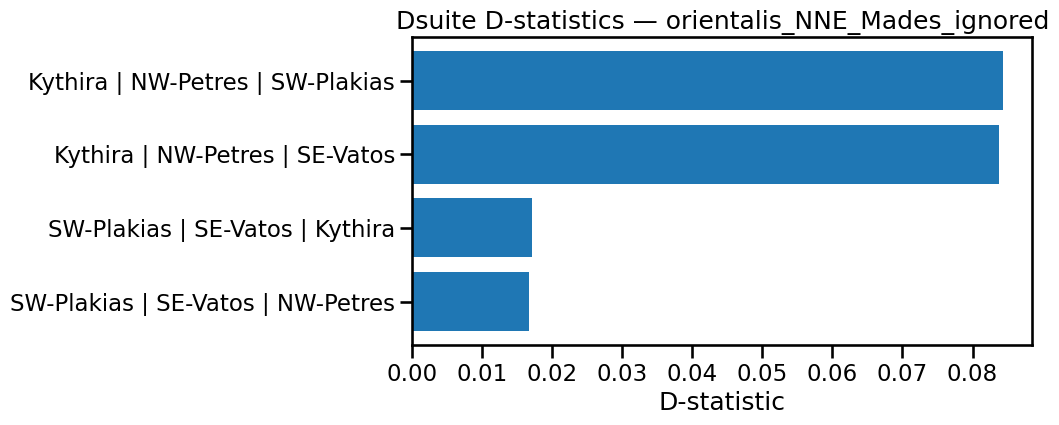

saved: /Users/maximilianwagner/Desktop/CretePopGenomics_local/results/figures/Dsuite_D_hofrichteri.png
saved: /Users/maximilianwagner/Desktop/CretePopGenomics_local/results/figures/Dsuite_D_hofrichteri.pdf


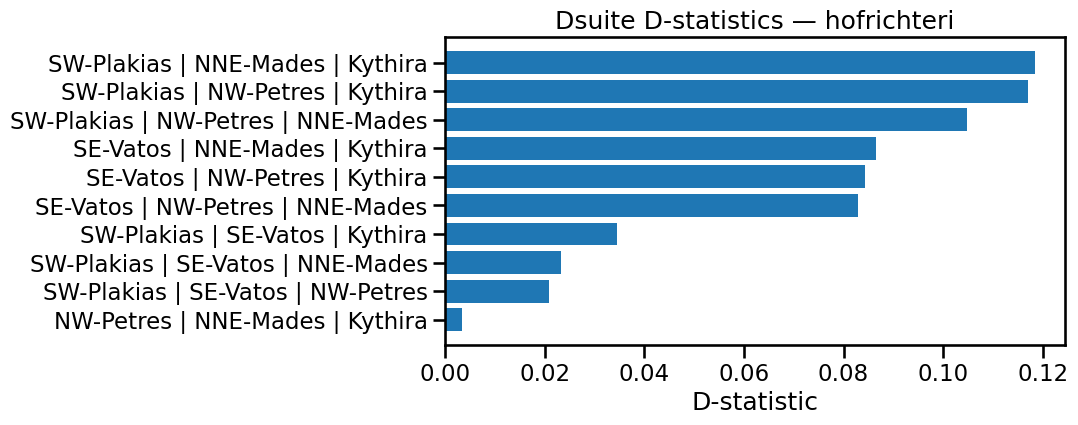

In [61]:
def plot_dsuite_d(df, title, outname):
    plot_df = df.copy()
    plot_df["trio"] = plot_df["P1"] + " | " + plot_df["P2"] + " | " + plot_df["P3"]
    plot_df = plot_df.sort_values("Dstatistic")
    fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(plot_df))))
    ax.barh(plot_df["trio"], plot_df["Dstatistic"])
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("D-statistic")
    ax.set_title(title)
    savefig(outname)
    plt.show()

for name, df in dsuite.items():
    plot_dsuite_d(df, f"Dsuite D-statistics — {name}", f"Dsuite_D_{name}")


## 11. ASTRAL population trees


In [62]:
for sp in SPECIES:
    tree = SNAKEMAKE / "astral" / f"ASTRAL.{sp}.60000.30000.diploid.tre"
    if tree.exists():
        print(f"{sp}: {tree}")
        print(tree.read_text()[:500], "...
")
    else:
        print(f"missing: {tree}")


SyntaxError: unterminated string literal (detected at line 5) (1393047744.py, line 5)

## 12. Genome scans: PBS, dA outliers, and overlap


In [ ]:
def get_pair_col(df, prefix, a, b):
    c1 = f"{prefix}_{a}_{b}"
    c2 = f"{prefix}_{b}_{a}"
    if c1 in df.columns:
        return c1
    if c2 in df.columns:
        return c2
    raise KeyError(f"No {prefix} column for {a}, {b}")


def add_pbs_for_trio(df, focal, b, c, label=None):
    label = label or f"PBS_{focal}_{b}_{c}"
    f_ab = pd.to_numeric(df[get_pair_col(df, "Fst", focal, b)], errors="coerce").clip(0, 0.999999)
    f_ac = pd.to_numeric(df[get_pair_col(df, "Fst", focal, c)], errors="coerce").clip(0, 0.999999)
    f_bc = pd.to_numeric(df[get_pair_col(df, "Fst", b, c)], errors="coerce").clip(0, 0.999999)
    out = df.copy()
    out[label] = (-np.log(1 - f_ab) + -np.log(1 - f_ac) - -np.log(1 - f_bc)) / 2
    return out


def kythira_pbs_outliers(species, percentile=0.95):
    df = popgen[species].copy()
    crete_pops = [p for p in POP_ORDER if p != "Kythira"]
    pbs_cols = []
    for b, c in itertools.combinations(crete_pops, 2):
        label = f"PBS_Kythira_{b}_{c}"
        df = add_pbs_for_trio(df, "Kythira", b, c, label)
        pbs_cols.append(label)
    for col in pbs_cols:
        df[f"{col}_outlier"] = df[col] >= df[col].quantile(percentile)
    df["PBS_Kythira_consensus_outlier"] = df[[f"{c}_outlier" for c in pbs_cols]].all(axis=1)
    return df, pbs_cols

pbs_results = {}
for sp in SPECIES:
    df, pbs_cols = kythira_pbs_outliers(sp)
    pbs_results[sp] = (df, pbs_cols)
    print(sp, "consensus PBS outliers:", int(df["PBS_Kythira_consensus_outlier"].sum()))
    df.to_csv(TABLES / f"{sp}_PBS_Kythira_windows.tsv.gz", sep="	", index=False, compression="gzip")


In [ ]:
def da_outliers_kythira_vs_crete(species, percentile=0.95):
    df = popgen[species].copy()
    crete_pops = [p for p in POP_ORDER if p != "Kythira"]
    k_cols = [get_pair_col(df, "dA", "Kythira", p) for p in crete_pops]
    crete_cols = [get_pair_col(df, "dA", a, b) for a, b in itertools.combinations(crete_pops, 2)]
    for col in k_cols:
        vals = pd.to_numeric(df[col], errors="coerce")
        df[f"{col}_outlier"] = vals >= vals.quantile(percentile)
    crete_out = pd.Series(False, index=df.index)
    for col in crete_cols:
        vals = pd.to_numeric(df[col], errors="coerce")
        crete_out |= vals >= vals.quantile(percentile)
    df["dA_Kythira_any_outlier"] = df[[f"{c}_outlier" for c in k_cols]].any(axis=1)
    df["dA_Crete_Crete_outlier"] = crete_out
    df["dA_Kythira_specific_outlier"] = df["dA_Kythira_any_outlier"] & ~df["dA_Crete_Crete_outlier"]
    return df

da_results = {}
for sp in SPECIES:
    df = da_outliers_kythira_vs_crete(sp)
    da_results[sp] = df
    print(sp, "Kythira-specific dA outliers:", int(df["dA_Kythira_specific_outlier"].sum()))
    df.to_csv(TABLES / f"{sp}_dA_Kythira_specific_windows.tsv.gz", sep="	", index=False, compression="gzip")


In [ ]:
candidate_windows = {}
for sp in SPECIES:
    pbs_df, _ = pbs_results[sp]
    da_df = da_results[sp]
    key = ["scaffold", "start", "end", "mid"]
    merged = pbs_df[key + ["PBS_Kythira_consensus_outlier"]].merge(
        da_df[key + ["dA_Kythira_specific_outlier"]], on=key, how="inner"
    )
    merged["candidate_window"] = merged["PBS_Kythira_consensus_outlier"] & merged["dA_Kythira_specific_outlier"]
    candidate_windows[sp] = merged
    out = TABLES / f"{sp}_candidate_windows_PBS_dA.tsv"
    merged.to_csv(out, sep="	", index=False)
    print(sp, int(merged["candidate_window"].sum()), out)

keys = ["scaffold", "start", "end"]
if all(sp in candidate_windows for sp in SPECIES):
    cand_a = candidate_windows["orientalis"].query("candidate_window")[keys]
    cand_b = candidate_windows["hofrichteri"].query("candidate_window")[keys]
    overlap = cand_a.merge(cand_b, on=keys, how="inner")
    overlap.to_csv(TABLES / "candidate_windows_overlap_orientalis_hofrichteri.tsv", sep="	", index=False)
    print("overlap windows:", len(overlap))
    display(overlap.head())


## 13. Candidate gene extraction from GTF


In [ ]:
GTF = EXTERNAL / "GCF_900634775.1_fGouWil2.1_genomic_chromnames.gtf"


def parse_gtf_attributes(attr):
    out = {}
    for item in str(attr).strip().split(";"):
        item = item.strip()
        if not item:
            continue
        if " " in item:
            k, v = item.split(" ", 1)
            out[k] = v.strip().strip('"')
    return out


def read_gtf_genes(gtf):
    cols = ["scaffold", "source", "feature", "start", "end", "score", "strand", "frame", "attributes"]
    df = pd.read_csv(require_file(gtf), sep="	", comment="#", header=None, names=cols)
    genes = df[df["feature"].isin(["gene", "transcript", "mRNA"])].copy()
    attrs = genes["attributes"].map(parse_gtf_attributes)
    genes["gene_id"] = attrs.map(lambda d: d.get("gene_id") or d.get("ID") or d.get("gene") or d.get("Name"))
    genes["gene_name"] = attrs.map(lambda d: d.get("gene_name") or d.get("Name") or d.get("gene") or d.get("gene_id"))
    return genes[["scaffold", "start", "end", "strand", "feature", "gene_id", "gene_name"]].drop_duplicates()

try:
    genes = read_gtf_genes(GTF)
    print(genes.shape)
    display(genes.head())
except FileNotFoundError as e:
    print(e)


In [ ]:
def extract_genes_for_windows(windows, genes, flank=30000):
    rows = []
    for _, w in windows.iterrows():
        chrom = str(w["scaffold"])
        mid = int(float(w["mid"])) if "mid" in w else int((int(w["start"]) + int(w["end"])) / 2)
        start = max(1, mid - flank)
        end = mid + flank
        sub = genes[(genes["scaffold"].astype(str) == chrom) & (genes["end"] >= start) & (genes["start"] <= end)].copy()
        if len(sub):
            sub["window_scaffold"] = chrom
            sub["window_start"] = w["start"]
            sub["window_end"] = w["end"]
            sub["window_mid"] = mid
            rows.append(sub)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

if "genes" in globals():
    for sp, wins in candidate_windows.items():
        cand = wins.query("candidate_window")
        gene_hits = extract_genes_for_windows(cand, genes, flank=30000)
        out = CANDIDATES / f"{sp}_candidate_window_genes_pm30kb.tsv"
        gene_hits.to_csv(out, sep="	", index=False)
        print(sp, gene_hits.shape, out)


# Appendix: exploratory and currently unused analyses


## Appendix A. Alternative PCA MAF thresholds


In [ ]:
for maf in ["0.01", "0.05", "0.1", "0.2", "0.4"]:
    for sp in SPECIES:
        try:
            df, var, _, _ = read_plink2_pca(sp, maf=maf)
            fig, ax = plt.subplots(figsize=(5, 4))
            for pop in POP_ORDER:
                sub = df[df["population"] == pop]
                if len(sub):
                    ax.scatter(sub["PC1"], sub["PC2"], label=pop, color=POP_COLORS.get(pop), s=35)
            ax.set_title(f"{sp} PCA MAF {maf}")
            ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
            ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
            savefig(f"appendix_PCA_{sp}_maf{maf}")
            plt.show()
        except FileNotFoundError:
            pass


## Appendix B. Alternative distance matrices for SplitsTree


In [ ]:
for maf in ["0.01", "0.05", "0.1", "0.2", "0.4"]:
    for sp in SPECIES:
        try:
            dist_file, id_file = distance_paths(sp, maf)
            dist = read_plink_square_dist(dist_file, id_file)
            out = write_phylip_square(dist, SPLITSTREE / f"appendix_{sp}_{SNP_SUFFIX}_maf{maf}.phy")
            print(out)
        except FileNotFoundError:
            pass


## Appendix C. Window diagnostics


In [ ]:
for sp, df in popgen.items():
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(pd.to_numeric(df["sites"], errors="coerce").dropna(), bins=50)
    ax.axvline(100, color="black", linestyle="--", lw=1)
    ax.set_title(f"Callable sites per window — {sp}")
    ax.set_xlabel("sites")
    ax.set_ylabel("number of windows")
    savefig(f"appendix_window_sites_{sp}")
    plt.show()


## Appendix D. Raw AF / snpEff tables


In [ ]:
def af_path(species):
    return SNAKEMAKE / "AF" / f"AF_{species}.tsv.gz"

for sp in SPECIES:
    path = af_path(sp)
    if path.exists():
        af = pd.read_csv(path, sep="	", compression="gzip", nrows=5)
        print(sp, path)
        display(af)
    else:
        print("missing", path)


## Appendix E. Hypergeometric overlap test template


In [ ]:
from scipy.stats import hypergeom

# Replace these values with final candidate window counts when needed.
M = None  # total number of windows analysed
n = None  # candidate windows in species 1
N = None  # candidate windows in species 2
k = None  # observed overlap

if all(x is not None for x in [M, n, N, k]):
    pval = hypergeom.sf(k - 1, M, n, N)
    expected = n * N / M
    enrichment = k / expected if expected else np.nan
    print({"pvalue": pval, "expected_overlap": expected, "enrichment": enrichment})
else:
    print("Fill in M, n, N, and k to run the hypergeometric overlap test.")
